# ==========================================================
# Breast Cancer Survival Prediction using Apache Spark
# Notebook 06: Model Interpretation & Explainability
# ==========================================================

"""
Objective
---------
1. Load the best-performing classification model.
2. Analyze feature importance.
3. Investigate misclassified samples.
4. Interpret prediction results from a clinical perspective.
5. Identify model limitations.
6. Propose future improvements.
7. Summarize the overall findings of the study.

Mục tiêu
---------
1. Nạp mô hình phân loại tốt nhất.
2. Phân tích mức độ quan trọng của các đặc trưng.
3. Phân tích các trường hợp dự đoán sai.
4. Diễn giải kết quả dưới góc độ lâm sàng.
5. Xác định các hạn chế của mô hình.
6. Đề xuất hướng cải tiến trong tương lai.
7. Tổng kết các kết quả đạt được của nghiên cứu.
"""

In [110]:
# 1. Import Libraries | Khai báo thư viện

print("\n" + "="*60)
print("1. IMPORT LIBRARIES")
print("="*60)

import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.ml import PipelineModel

from pyspark.ml.classification import (
    LogisticRegressionModel,
    DecisionTreeClassificationModel,
    RandomForestClassificationModel,
    GBTClassificationModel
)

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Visualization Style Configuration

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    
from src.data.loader import create_spark_session
print("Libraries imported successfully.")


1. IMPORT LIBRARIES
Libraries imported successfully.


In [111]:
# 2. Create Spark Session | Khởi tạo Spark Session

print("\n"+"="*60)
print("2. CREATE SPARK SESSION")
print("="*60)

spark = create_spark_session("SEER Breast Cancer Model Interpretation")
print("Spark Session created successfully.")


2. CREATE SPARK SESSION
Spark Session created successfully.


In [112]:
# 3. Define Project Paths | Định nghĩa đường dẫn dự án

print("\n" + "=" * 60)
print("3. DEFINE PROJECT PATHS")
print("=" * 60)

MODEL_PATH = "../models/trained_models"

BEST_MODEL_PATH = "../models/best_model.txt"

DATA_PATH = "../data/processed/test_dataset.parquet"

REPORT_PATH = "../reports"

TABLE_PATH = os.path.join(
    REPORT_PATH,
    "tables"
)

FIGURE_PATH = os.path.join(
    REPORT_PATH,
    "figures"
)

RESULT_PATH = "../results"

os.makedirs(TABLE_PATH, exist_ok=True)
os.makedirs(FIGURE_PATH, exist_ok=True)
os.makedirs(RESULT_PATH, exist_ok=True)

print("Project paths initialized successfully.")


3. DEFINE PROJECT PATHS
Project paths initialized successfully.


In [113]:
# 4. Load Best Model Name | Đọc tên mô hình tốt nhất

print("\n" + "="*60)
print("4. LOAD BEST MODEL NAME")
print("="*60)

with open(BEST_MODEL_PATH, "r") as f:
    best_model_name = f.read().strip()

print(f"Selected Model : {best_model_name}")


4. LOAD BEST MODEL NAME
Selected Model : GBT Classifier


In [114]:
# 5. Load Feature Metadata | Nạp Metadata đặc trưng

print("\n" + "="*60)
print("5. LOAD FEATURE METADATA")
print("="*60)

DATA_PATH = "../data/processed/test_dataset.parquet"
test_df = spark.read.parquet(DATA_PATH)

if "weight" not in test_df.columns:
    test_df = test_df.withColumn("weight",F.lit(1.0))

print(f"Testing dataset loaded: {test_df.count():,} rows")


5. LOAD FEATURE METADATA


Testing dataset loaded: 90,756 rows


In [115]:
# 6. Load Best Model | Nạp mô hình tốt nhất

print("\n" + "="*60)
print("6. LOAD BEST MODEL")
print("="*60)

def spark_local_path(path):
       path = os.path.abspath(path)
       return "file:///" + path.replace("\\", "/")

model_mapping = {
    "Logistic Regression": LogisticRegressionModel,
    "Decision Tree": DecisionTreeClassificationModel,
    "Random Forest": RandomForestClassificationModel,
    "GBT Classifier": GBTClassificationModel
}

model_file = (best_model_name.lower().replace(" ", "_")+ "_model")

model_path = os.path.join(MODEL_PATH,model_file)
best_model = model_mapping[best_model_name].load(spark_local_path(model_path))

print("Best model loaded successfully.")


6. LOAD BEST MODEL
Best model loaded successfully.


In [116]:
# 7. Load Preprocessing Pipeline | Nạp Pipeline tiền xử lý

print("\n" + "=" * 60)
print("7. LOAD PREPROCESSING PIPELINE")
print("=" * 60)

if best_model_name == "Logistic Regression":
    pipeline_name = "logistic_regression_pipeline"
else:
    pipeline_name = "tree_models_pipeline"

pipeline_path = os.path.join(MODEL_PATH,pipeline_name)
pipeline = PipelineModel.load(spark_local_path(pipeline_path))

print(f"Pipeline Loaded : {pipeline_name}")


7. LOAD PREPROCESSING PIPELINE
Pipeline Loaded : tree_models_pipeline


In [117]:
# 8. Load Test Dataset | Nạp tập dữ liệu kiểm thử

print("\n" + "=" * 60)
print("8. LOAD TEST DATASET")
print("=" * 60)

test_df = spark.read.parquet(DATA_PATH)

if "weight" not in test_df.columns:test_df = test_df.withColumn("weight",F.lit(1.0))

print(f"Testing Rows : {test_df.count():,}")
print("Test dataset loaded successfully.")


8. LOAD TEST DATASET
Testing Rows : 90,756
Test dataset loaded successfully.


In [118]:
# 9. Dataset Overview | Tổng quan dữ liệu

print("\n" + "=" * 60)
print("9. DATASET OVERVIEW")
print("=" * 60)

processed_test = pipeline.transform(test_df)

predictions = best_model.transform(processed_test)

print("Prediction generated successfully.")

print(f"Best Model      : {best_model_name}")
print(f"Testing Rows    : {predictions.count():,}")
print(f"Total Columns   : {len(predictions.columns)}")

print("\nLabel Distribution")

(
    predictions
    .groupBy("label")
    .count()
    .orderBy("label")
    .show()
)

print("""
Label Mapping
0 -> Alive
1 -> Dead
""")


9. DATASET OVERVIEW
Prediction generated successfully.
Best Model      : GBT Classifier
Testing Rows    : 90,756
Total Columns   : 50

Label Distribution
+-----+-----+
|label|count|
+-----+-----+
|    0|57174|
|    1|33582|
+-----+-----+


Label Mapping
0 -> Alive
1 -> Dead



In [119]:
# 10. Feature Importance Analysis | Phân tích tầm quan trọng đặc trưng

print("\n" + "=" * 60)
print("10. FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Extract feature names from Spark metadata

metadata = predictions.schema["features"].metadata
feature_names = []

if "ml_attr" in metadata:
    attrs = metadata["ml_attr"]["attrs"]
    for attr_type in attrs:
        for item in attrs[attr_type]:
            feature_names.append(item["name"])

print(f"Total transformed features: {len(feature_names)}")

# Extract feature importance

if best_model_name == "Logistic Regression":
    print("Model Type : Logistic Regression")
    print("Using absolute coefficient values.")
    values = best_model.coefficients.toArray()
    contribution_name = "Coefficient"

else:
    print(f"Model Type : {best_model_name}")
    print("Using tree-based feature importance.")
    values = best_model.featureImportances.toArray()
    contribution_name = "Importance"

# Prevent feature mismatch

if len(feature_names) != len(values):
    print("WARNING : Feature size mismatch detected.")
    min_size = min(len(feature_names),len(values))
    feature_names = feature_names[:min_size]
    values = values[:min_size]

# Create DataFrame

feature_df = pd.DataFrame({"Feature": feature_names,contribution_name: values})
feature_df["Absolute_Impact"] = (feature_df[contribution_name].abs())

feature_df = (feature_df.sort_values("Absolute_Impact",ascending=False))

print(feature_df.head(20))


10. FEATURE IMPORTANCE ANALYSIS
Total transformed features: 24
Model Type : GBT Classifier
Using tree-based feature importance.
                               Feature  Importance  Absolute_Impact
19                   Age_Group_indexed    0.249271         0.249271
7               Marital_Status_indexed    0.137572         0.137572
18                Chemotherapy_indexed    0.108804         0.108804
2              Regional_Nodes_Examined    0.089623         0.089623
1                           Tumor_Size    0.065694         0.065694
21              Hormone_Status_indexed    0.062307         0.062307
4                           Node_Ratio    0.044983         0.044983
17                   Radiation_indexed    0.038441         0.038441
16  Surgery_Radiation_Sequence_indexed    0.036390         0.036390
11                      AJCC_M_indexed    0.032347         0.032347
3              Regional_Nodes_Positive    0.032184         0.032184
23        Surgery_Primary_Site_indexed    0.025359     

In [120]:
# 11. Rank Top Important Features | Xếp hạng đặc trưng quan trọng

print("\n" + "=" * 60)
print("11. RANK TOP IMPORTANT FEATURES")
print("=" * 60)

top20_features = feature_df.head(20)

print("Top 20 Most Important Features")
print("-" * 60)

display(top20_features)

top20_features.to_csv(os.path.join(TABLE_PATH,"feature_importance.csv"),index=False)

print("\nFeature importance table saved successfully.")


11. RANK TOP IMPORTANT FEATURES
Top 20 Most Important Features
------------------------------------------------------------


,Feature,Importance,Absolute_Impact
19,Age_Group_indexed,0.249271,0.249271
7,Marital_Status_indexed,0.137572,0.137572
18,Chemotherapy_indexed,0.108804,0.108804
2,Regional_Nodes_Examined,0.089623,0.089623
1,Tumor_Size,0.065694,0.065694
21,Hormone_Status_indexed,0.062307,0.062307
4,Node_Ratio,0.044983,0.044983
17,Radiation_indexed,0.038441,0.038441
16,Surgery_Radiation_Sequence_indexed,0.036390,0.036390
11,AJCC_M_indexed,0.032347,0.032347



Feature importance table saved successfully.



12. FEATURE IMPORTANCE VISUALIZATION


C:\Users\HOANG YEN\AppData\Local\Temp\ipykernel_34980\1880002201.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=top_features, x="Absolute_Impact", y="Feature", palette="viridis")


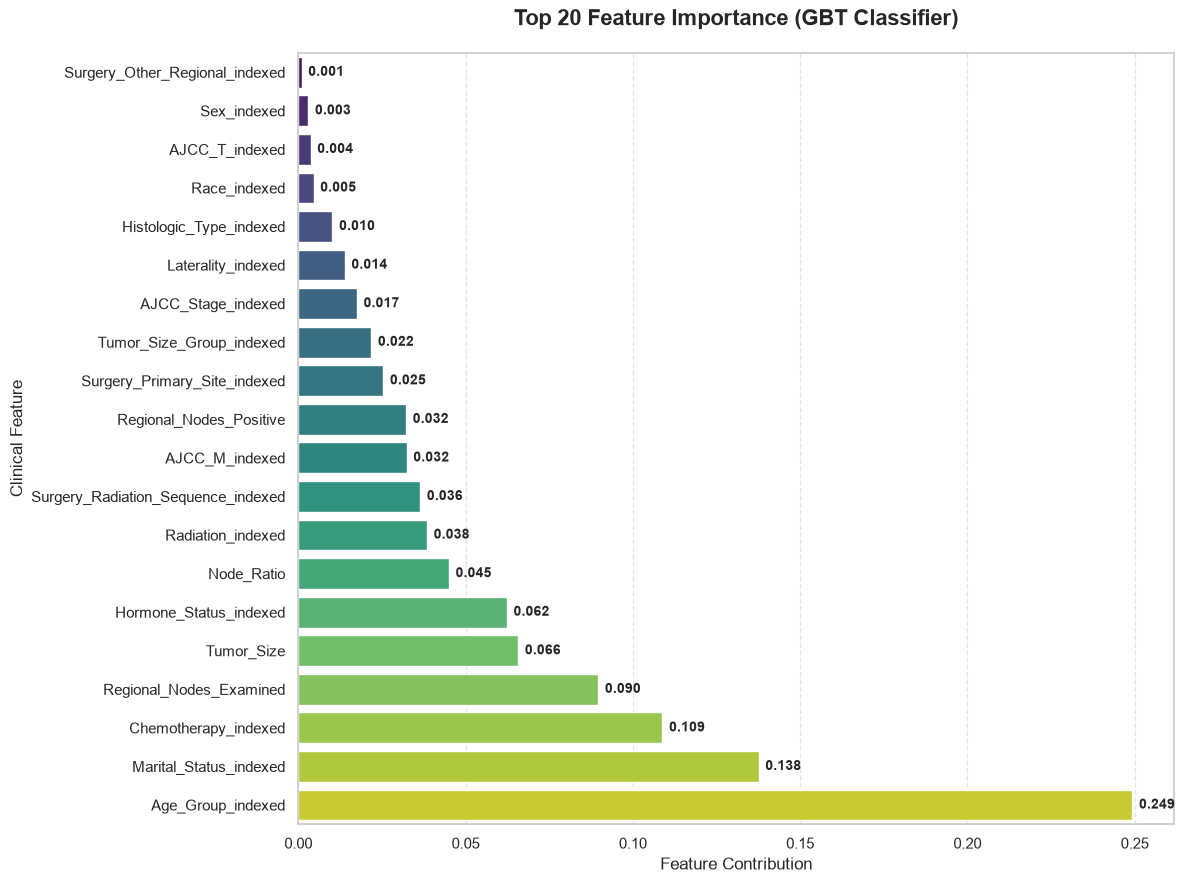

In [121]:
# 12. Feature Importance Visualization | Trực quan hóa độ quan trọng của đặc trưng

print("\n" + "=" * 60)
print("12. FEATURE IMPORTANCE VISUALIZATION")
print("=" * 60)

plt.figure(figsize=(12, 9))
top_features = top20_features.sort_values("Absolute_Impact", ascending=True)

bars = sns.barplot(data=top_features, x="Absolute_Impact", y="Feature", palette="viridis")

for bar in bars.patches:
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.3f}", va="center", fontsize=10, fontweight="bold")

plt.title(f"Top 20 Feature Importance ({best_model_name})", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Feature Contribution", fontsize=12)
plt.ylabel("Clinical Feature", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/top20_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


13. FEATURE CATEGORY IMPORTANCE


C:\Users\HOANG YEN\AppData\Local\Temp\ipykernel_34980\910067053.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=category_df, x="Category", y="Absolute_Impact", palette="magma")


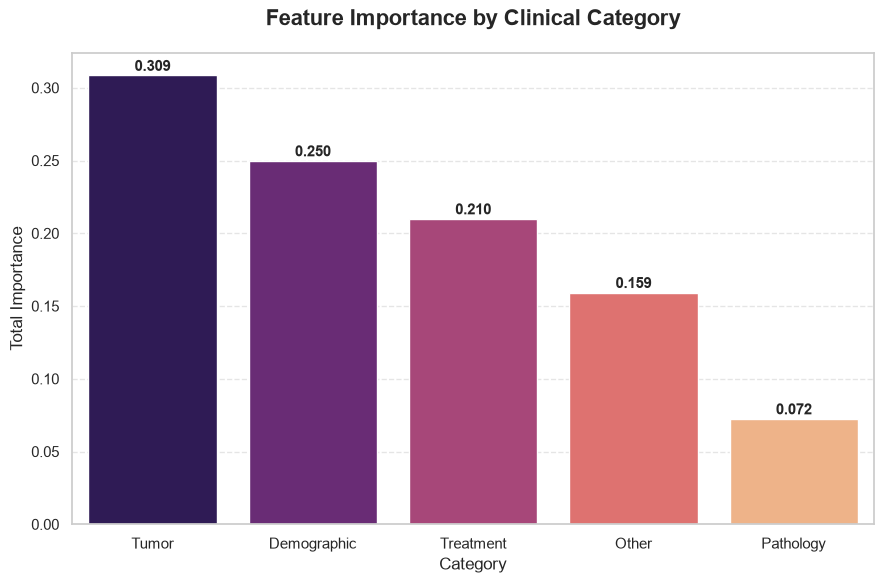

In [122]:
# 13. Feature Category Importance | Độ quan trọng theo danh mục đặc trưng

print("\n" + "=" * 60)
print("13. FEATURE CATEGORY IMPORTANCE")
print("=" * 60)

plt.figure(figsize=(9, 6))
bars = sns.barplot(data=category_df, x="Category", y="Absolute_Impact", palette="magma")

for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(category_df["Absolute_Impact"])*0.01), 
             f"{bar.get_height():.3f}", ha="center", fontsize=11, fontweight="bold")

plt.title("Feature Importance by Clinical Category", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Importance", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/feature_category_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [123]:
# 14. Analyze Misclassified Samples | Phân tích các mẫu dự đoán sai

print("\n" + "=" * 60)
print("14. ANALYZE MISCLASSIFIED SAMPLES")
print("=" * 60)

misclassified = predictions.filter(F.col("label") != F.col("prediction"))
misclassified_count = misclassified.count()

print(f"Total Misclassified Samples : {misclassified_count:,}")

misclassified.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

misclassified.write \
    .mode("overwrite") \
    .parquet("../results/misclassified_samples.parquet")

print("Misclassified samples exported successfully.")


14. ANALYZE MISCLASSIFIED SAMPLES
Total Misclassified Samples : 19,364
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1    |0.0       |[0.7909756345820623,0.20902436541793767]|
|1    |0.0       |[0.8138621504493725,0.1861378495506275] |
|1    |0.0       |[0.9134534534087325,0.08654654659126748]|
|1    |0.0       |[0.6953529275968211,0.3046470724031789] |
|1    |0.0       |[0.7032617938270352,0.29673820617296476]|
|0    |1.0       |[0.36640782391353904,0.6335921760864609]|
|1    |0.0       |[0.7694920276482888,0.23050797235171117]|
|1    |0.0       |[0.7309425179226209,0.2690574820773791] |
|0    |1.0       |[0.3484109077412803,0.6515890922587197] |
|0    |1.0       |[0.47784011621568956,0.5221598837843104]|
+-----+----------+----------------------------------------+
only showing top 10 rows

Misclassified samples exported successfully.


In [124]:
# 15. False Positive Analysis | Phân tích False Positive

print("\n" + "=" * 60)
print("15. FALSE POSITIVE ANALYSIS")
print("=" * 60)

false_positive = predictions.filter(
    (F.col("label") == 0) &
    (F.col("prediction") == 1)
)

fp_count = false_positive.count()

print(f"False Positive Samples : {fp_count:,}")
print()

print("Preview")
false_positive.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

false_positive.write \
    .mode("overwrite") \
    .parquet("../results/false_positive_samples.parquet")

print("False Positive samples exported.")


15. FALSE POSITIVE ANALYSIS
False Positive Samples : 10,332

Preview
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |1.0       |[0.36640782391353904,0.6335921760864609]|
|0    |1.0       |[0.3484109077412803,0.6515890922587197] |
|0    |1.0       |[0.47784011621568956,0.5221598837843104]|
|0    |1.0       |[0.32888055225025464,0.6711194477497453]|
|0    |1.0       |[0.38576515552982904,0.614234844470171] |
|0    |1.0       |[0.31095743895408373,0.6890425610459163]|
|0    |1.0       |[0.3842665109079062,0.6157334890920938] |
|0    |1.0       |[0.3744814946357247,0.6255185053642753] |
|0    |1.0       |[0.05121638999916334,0.9487836100008367]|
|0    |1.0       |[0.3965495997314765,0.6034504002685235] |
+-----+----------+----------------------------------------+
only showing top 10 rows

False Positive samples exported.


In [125]:
# 16. False Negative Analysis | Phân tích False Negative

print("\n" + "=" * 60)
print("16. FALSE NEGATIVE ANALYSIS")
print("=" * 60)

false_negative = predictions.filter(
    (F.col("label") == 1) &
    (F.col("prediction") == 0)
)

fn_count = false_negative.count()

print(f"False Negative Samples : {fn_count:,}")
print()
print("Preview")

false_negative.select("label","prediction","probability").show(10, truncate=False)

false_negative.write \
    .mode("overwrite") \
    .parquet("../results/false_negative_samples.parquet")

print("False Negative samples exported.")


16. FALSE NEGATIVE ANALYSIS
False Negative Samples : 9,032

Preview
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1    |0.0       |[0.7909756345820623,0.20902436541793767]|
|1    |0.0       |[0.8138621504493725,0.1861378495506275] |
|1    |0.0       |[0.9134534534087325,0.08654654659126748]|
|1    |0.0       |[0.6953529275968211,0.3046470724031789] |
|1    |0.0       |[0.7032617938270352,0.29673820617296476]|
|1    |0.0       |[0.7694920276482888,0.23050797235171117]|
|1    |0.0       |[0.7309425179226209,0.2690574820773791] |
|1    |0.0       |[0.593411794917899,0.40658820508210103] |
|1    |0.0       |[0.7220541572780051,0.27794584272199485]|
|1    |0.0       |[0.5538766137418795,0.44612338625812054]|
+-----+----------+----------------------------------------+
only showing top 10 rows

False Negative samples exported.


In [126]:
# 17. Error Analysis Summary | Tổng hợp các loại lỗi

print("\n" + "=" * 60)
print("17. ERROR ANALYSIS SUMMARY")
print("=" * 60)

TP = predictions.filter(
    (F.col("label") == 1) &
    (F.col("prediction") == 1)
).count()

TN = predictions.filter(
    (F.col("label") == 0) &
    (F.col("prediction") == 0)
).count()

FP = predictions.filter(
    (F.col("label") == 0) &
    (F.col("prediction") == 1)
).count()

FN = predictions.filter(
    (F.col("label") == 1) &
    (F.col("prediction") == 0)
).count()

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)
f1 = 2 * precision * recall / (precision + recall)

fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print(f"True Positive        : {TP:,}")
print(f"True Negative        : {TN:,}")
print(f"False Positive       : {FP:,}")
print(f"False Negative       : {FN:,}")
print()

print(f"Accuracy             : {accuracy:.4f}")
print(f"Precision            : {precision:.4f}")
print(f"Recall (Sensitivity) : {recall:.4f}")
print(f"Specificity          : {specificity:.4f}")
print(f"F1-score             : {f1:.4f}")
print()

print(f"False Positive Rate  : {fpr:.4f}")
print(f"False Negative Rate  : {fnr:.4f}")

error_summary = pd.DataFrame({
    "Metric": [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1-score",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Value": [
        TP,
        TN,
        FP,
        FN,
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        fpr,
        fnr
    ]
})

display(error_summary)
error_summary.to_csv(os.path.join(TABLE_PATH, "error_analysis_summary.csv"),index=False)

print("Error summary exported successfully.")


17. ERROR ANALYSIS SUMMARY
True Positive        : 24,550
True Negative        : 46,842
False Positive       : 10,332
False Negative       : 9,032

Accuracy             : 0.7866
Precision            : 0.7038
Recall (Sensitivity) : 0.7310
Specificity          : 0.8193
F1-score             : 0.7172

False Positive Rate  : 0.1807
False Negative Rate  : 0.2690


,Metric,Value
0,True Positive,24550.000000
1,True Negative,46842.000000
2,False Positive,10332.000000
3,False Negative,9032.000000
4,Accuracy,0.786637
5,Precision,0.703801
6,Recall,0.731046
7,Specificity,0.819288
8,F1-score,0.717165
9,False Positive Rate,0.180712


Error summary exported successfully.



18. FEATURE CATEGORY IMPORTANCE


C:\Users\HOANG YEN\AppData\Local\Temp\ipykernel_34980\1453222981.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


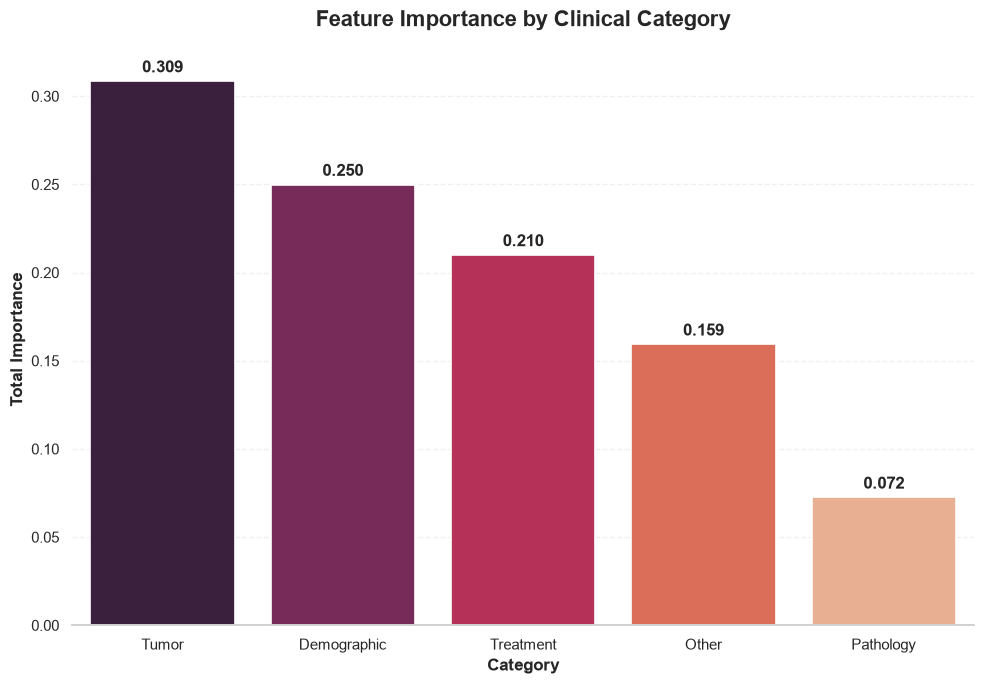

In [127]:
# 18. Feature Category Importance | Độ quan trọng theo danh mục đặc trưng

print("\n" + "=" * 60)
print("18. FEATURE CATEGORY IMPORTANCE")
print("=" * 60)

plt.figure(figsize=(10, 7))

category_df_sorted = category_df.sort_values("Absolute_Impact", ascending=False)
bars = sns.barplot(
    data=category_df_sorted, 
    x="Category", 
    y="Absolute_Impact", 
    palette="rocket",
    edgecolor="white",
    linewidth=1.2
)

for bar in bars.patches:
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.005, 
        f"{bar.get_height():.3f}", 
        ha="center", 
        fontsize=12, 
        fontweight="bold"
    )

plt.title("Feature Importance by Clinical Category", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Category", fontsize=12, fontweight="bold")
plt.ylabel("Total Importance", fontsize=12, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine(left=True)

plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/feature_category_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [128]:
# 19. Prediction Probability Analysis | Phân tích xác suất dự đoán

print("\n" + "=" * 60)
print("19. PREDICTION PROBABILITY ANALYSIS")
print("=" * 60)

# Used for ROC, PR Curve and Threshold Analysis

threshold_df = predictions.select("label","prediction","probability").toPandas()

# Extract probability of Dead class (label = 1)
threshold_df["dead_probability"] = (threshold_df["probability"].apply(lambda x: float(x[1])))

print(f"Total Samples : {len(threshold_df):,}")

display(threshold_df.head())
print("Prediction probability dataset created successfully.")


19. PREDICTION PROBABILITY ANALYSIS
Total Samples : 90,756


,label,prediction,probability,dead_probability
0,0,0.0,"[0.7827314353662786, 0.21726856463372135]",0.217269
1,0,0.0,"[0.530228908829619, 0.46977109117038096]",0.469771
2,1,0.0,"[0.7909756345820623, 0.20902436541793767]",0.209024
3,1,1.0,"[0.2789124868985308, 0.7210875131014691]",0.721088
4,0,0.0,"[0.5409310913695594, 0.4590689086304406]",0.459069


Prediction probability dataset created successfully.



20. ROC CURVE ANALYSIS


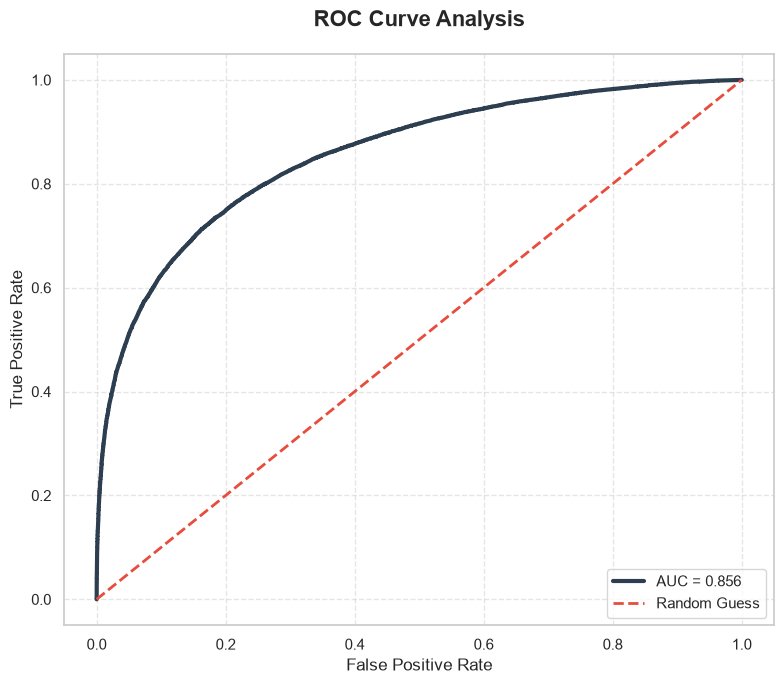

In [129]:
# 20. ROC Curve Analysis | Phân tích đường cong ROC

print("\n" + "=" * 60)
print("20. ROC CURVE ANALYSIS")
print("=" * 60)

from sklearn.metrics import roc_curve, auc

threshold_df["dead_probability"] = threshold_df["probability"].apply(lambda x: float(x[1]))
fpr, tpr, _ = roc_curve(threshold_df["label"], threshold_df["dead_probability"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color="#2c3e50", linewidth=3, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color="#e74c3c", linestyle="--", linewidth=2, label="Random Guess")

plt.title("ROC Curve Analysis", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


21. PRECISION-RECALL CURVE


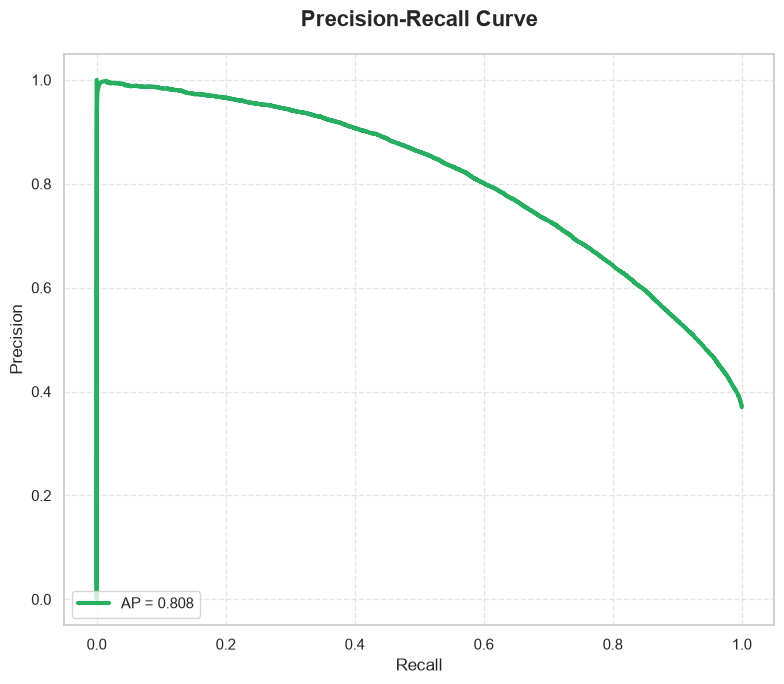

In [130]:
# 21. Precision-Recall Curve | Đường cong Precision-Recall

print("\n" + "=" * 60)
print("21. PRECISION-RECALL CURVE")
print("=" * 60)

from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(threshold_df["label"], threshold_df["dead_probability"])
ap = average_precision_score(threshold_df["label"], threshold_df["dead_probability"])

plt.figure(figsize=(8, 7))
plt.plot(recall, precision, color="#27ae60", linewidth=3, label=f"AP = {ap:.3f}")

plt.title("Precision-Recall Curve", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend(loc="lower left", fontsize=11)
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [131]:
# 22. Threshold Tuning Analysis | Phân tích điều chỉnh ngưỡng

print("""
Threshold Tuning Analysis
=========================

The default threshold of 0.50 was further investigated.

In survival prediction problems, False Negative errors
are clinically important because high-risk patients
may be incorrectly classified as survivors.

Therefore, different decision thresholds were evaluated:

0.35
0.40
0.45
0.50

The objective is to analyze the trade-off between:

- Recall (Sensitivity)
- False Negative Rate
- Overall Accuracy

""")


Threshold Tuning Analysis

The default threshold of 0.50 was further investigated.

In survival prediction problems, False Negative errors
are clinically important because high-risk patients
may be incorrectly classified as survivors.

Therefore, different decision thresholds were evaluated:

0.35
0.40
0.45
0.50

The objective is to analyze the trade-off between:

- Recall (Sensitivity)
- False Negative Rate
- Overall Accuracy




In [132]:
# 23. Threshold Comparison | So sánh các ngưỡng

print("\n" + "=" * 60)
print("23. THRESHOLD COMPARISON")
print("=" * 60)

threshold_results = []
threshold_values = [0.35, 0.40, 0.45, 0.50]

for threshold in threshold_values:
    y_true = threshold_df["label"]
    y_pred = (threshold_df["dead_probability"] >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "False Positive": fp,
        "False Negative": fn,
        "False Positive Rate": fp / (fp + tn) if (fp + tn) > 0 else 0,
        "False Negative Rate": fn / (fn + tp) if (fn + tp) > 0 else 0
    })

# Tạo DataFrame và định dạng hiển thị chuyên nghiệp
threshold_results_df = pd.DataFrame(threshold_results)

# Hiển thị bảng với style làm nổi bật giá trị
display(threshold_results_df.style
        .format({col: "{:.4f}" for col in threshold_results_df.columns if col not in ["Threshold", "False Positive", "False Negative"]})
        .background_gradient(cmap="Blues", subset=["Accuracy", "F1-score"])
        .set_properties(**{'text-align': 'center'}))

# Export results
threshold_results_df.to_csv(os.path.join(TABLE_PATH, "threshold_comparison.csv"), index=False)

print("\nThreshold comparison exported successfully to: " + TABLE_PATH + "/threshold_comparison.csv")


23. THRESHOLD COMPARISON


,Threshold,Accuracy,Precision,Recall,F1-score,Specificity,False Positive,False Negative,False Positive Rate,False Negative Rate
0,0.350000,0.7378,0.6051,0.8387,0.7030,0.6785,18379,5417,0.3215,0.1613
1,0.400000,0.7590,0.6384,0.8040,0.7117,0.7325,15292,6582,0.2675,0.1960
2,0.450000,0.7755,0.6721,0.7677,0.7167,0.7800,12579,7800,0.2200,0.2323
3,0.500000,0.7866,0.7038,0.7310,0.7172,0.8193,10332,9032,0.1807,0.2690



Threshold comparison exported successfully to: ../reports\tables/threshold_comparison.csv



24. THRESHOLD PERFORMANCE VISUALIZATION


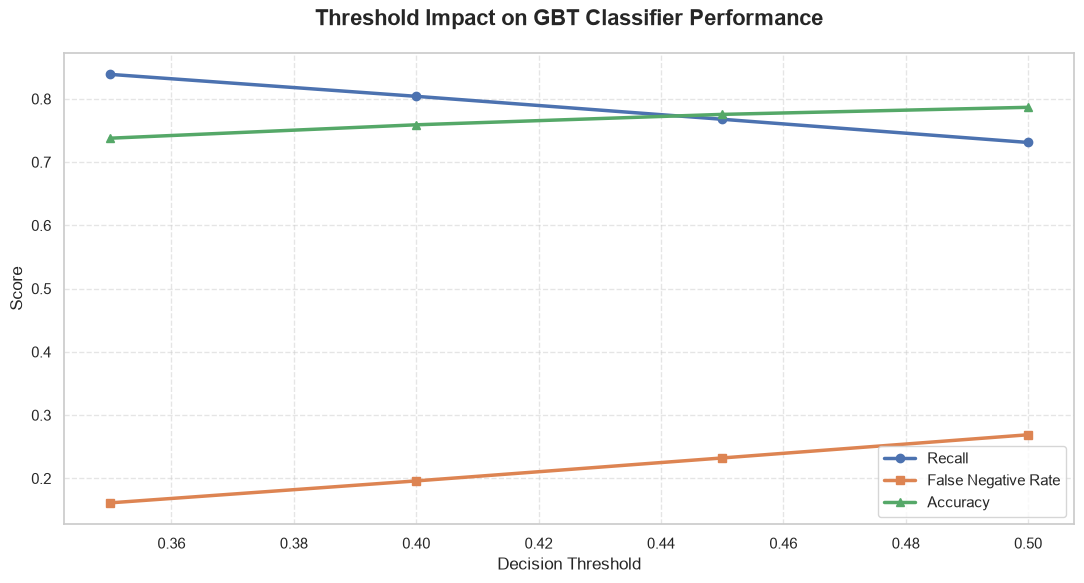

In [133]:
# 24. Threshold Performance Visualization | Trực quan hóa hiệu quả ngưỡng

print("\n" + "=" * 60)
print("24. THRESHOLD PERFORMANCE VISUALIZATION")
print("=" * 60)

plt.figure(figsize=(11, 6))
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall"], marker="o", linewidth=2.5, label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["False Negative Rate"], marker="s", linewidth=2.5, label="False Negative Rate")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Accuracy"], marker="^", linewidth=2.5, label="Accuracy")

plt.title("Threshold Impact on GBT Classifier Performance", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Decision Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(fontsize=11)
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/threshold_analysis.png", dpi=300, bbox_inches="tight")
plt.show()


25. CONFUSION MATRIX


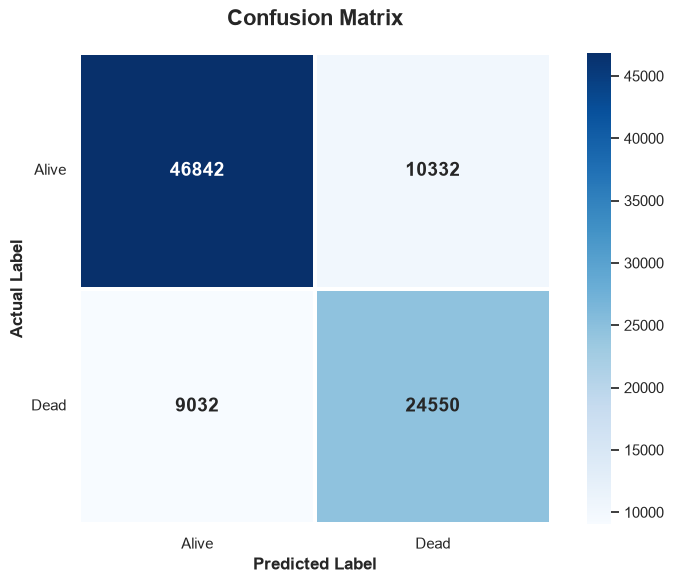

In [134]:
# 25. Confusion Matrix | Ma trận nhầm lẫn

print("\n" + "=" * 60)
print("25. CONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(
    predictions.select("label").toPandas(),
    predictions.select("prediction").toPandas()
)

cm_df = pd.DataFrame(cm, index=["Alive", "Dead"], columns=["Alive", "Dead"])

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_df, 
    annot=True, 
    fmt="d", 
    cmap="Blues",       
    cbar=True,       
    linewidths=1.5, 
    linecolor="white",
    annot_kws={"fontsize": 14, "fontweight": "bold"},
    square=True
)

plt.title("Confusion Matrix", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")
plt.ylabel("Actual Label", fontsize=12, fontweight="bold")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()


26. PREDICTION CONFIDENCE ANALYSIS


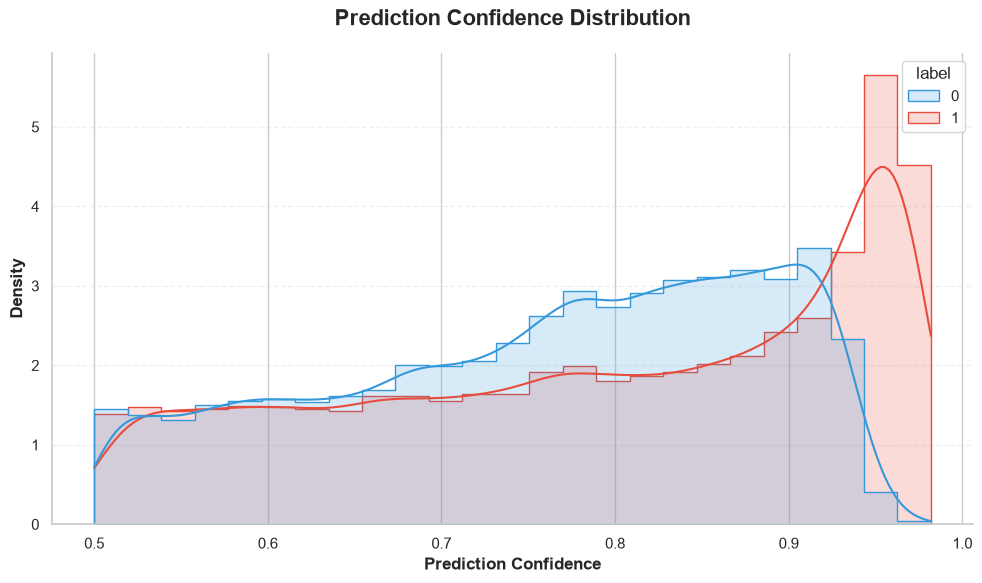

,label,prediction,confidence
count,90756.000000,90756.000000,90756.000000
mean,0.370025,0.384349,0.771170
std,0.482814,0.486444,0.132172
min,0.000000,0.000000,0.500007
25%,0.000000,0.000000,0.667887
50%,0.000000,0.000000,0.788303
75%,1.000000,1.000000,0.884436
max,1.000000,1.000000,0.981897


In [135]:
# 26. Prediction Confidence Analysis | Phân tích độ tin cậy dự đoán

print("\n" + "=" * 60)
print("26. PREDICTION CONFIDENCE ANALYSIS")
print("=" * 60)

confidence_df = predictions.select("label", "prediction", "probability").toPandas()
confidence_df["confidence"] = confidence_df["probability"].apply(lambda x: float(max(x)))

plt.figure(figsize=(10, 6))

sns.histplot(
    data=confidence_df, 
    x="confidence", 
    hue="label", 
    bins=25, 
    kde=True, 
    stat="density", 
    common_norm=False,
    palette=["#3498db", "#e74c3c"],
    element="step",
    alpha=0.2
)

plt.title("Prediction Confidence Distribution", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Prediction Confidence", fontsize=12, fontweight="bold")
plt.ylabel("Density", fontsize=12, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, "prediction_confidence.png"), dpi=300, bbox_inches="tight")
plt.show()

display(confidence_df.describe())

# 27. Clinical Interpretation | Diễn giải lâm sàng

print("\n" + "=" * 60)
print("27. CLINICAL INTERPRETATION")
print("=" * 60)

print("""

Clinical Interpretation
=======================

1. Age
Older patients generally have a higher mortality risk.
Age was identified as one of the most influential predictors
in the GBT model.

2. Tumor Characteristics
Tumor Size and Node Ratio were among the most important
clinical variables because they reflect disease severity
and tumor progression.

3. AJCC Staging
AJCC staging variables contributed significantly to
survival prediction by describing tumor invasion,
lymph node involvement, and distant metastasis.

4. Prediction Errors
False Negative cases are clinically important because
patients with poor outcomes were incorrectly predicted
as survivors. In real clinical practice, this type of
error may delay treatment planning and patient monitoring.

----------------------------------------------------------------

Diễn giải lâm sàng
==================

1. Tuổi
Bệnh nhân lớn tuổi thường có nguy cơ tử vong cao hơn.
Độ tuổi được xác định là một trong những đặc trưng có
mức ảnh hưởng lớn nhất trong mô hình GBT.

2. Đặc điểm khối u
Kích thước khối u (Tumor Size) và tỷ lệ hạch dương tính
(Node Ratio) là những đặc trưng quan trọng vì phản ánh
mức độ tiến triển và mức độ nghiêm trọng của bệnh.

3. Giai đoạn AJCC
Các biến AJCC cung cấp thông tin về mức độ xâm lấn của
khối u, tình trạng hạch bạch huyết và di căn xa,
qua đó góp phần quan trọng vào việc dự đoán khả năng sống còn.

4. Sai số dự đoán
Các trường hợp False Negative có ý nghĩa đặc biệt trong
lâm sàng vì bệnh nhân tử vong lại được dự đoán là còn sống.
Điều này có thể làm chậm quá trình điều trị hoặc theo dõi
đối với những bệnh nhân có nguy cơ cao.

""")


28. CLINICAL RISK ANALYSIS


C:\Users\HOANG YEN\AppData\Local\Temp\ipykernel_34980\3980890496.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


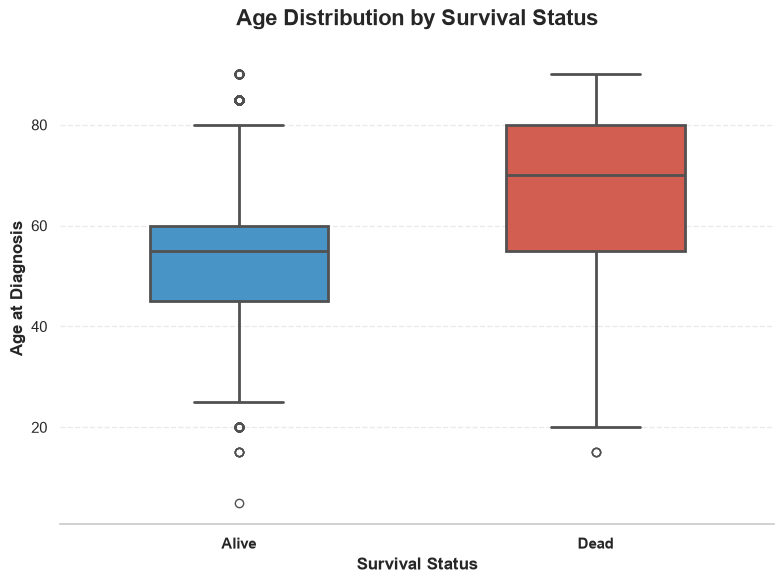

Clinical risk analysis saved successfully.


In [136]:
# 28. Clinical Risk Analysis | Phân tích nguy cơ lâm sàng

print("\n" + "=" * 60)
print("28. CLINICAL RISK ANALYSIS")
print("=" * 60)

clinical_df = test_df.select(
    "Age",
    "Tumor_Size",
    "AJCC_Stage",
    "label"
).toPandas()

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=clinical_df,
    x="label",
    y="Age",
    palette=["#3498db", "#e74c3c"],
    width=0.5,
    linewidth=2
)

plt.xticks([0, 1], ["Alive", "Dead"], fontsize=11, fontweight="bold")
plt.title("Age Distribution by Survival Status", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Survival Status", fontsize=12, fontweight="bold")
plt.ylabel("Age at Diagnosis", fontsize=12, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine(left=True)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, "clinical_age_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Clinical risk analysis saved successfully.")

# ==========================================================
# 29. Model Limitations | Hạn chế của mô hình
# ==========================================================

print("\n" + "=" * 60)
print("29. MODEL LIMITATIONS")
print("=" * 60)

print("""

Model Limitations
=================

1. The SEER dataset only contains structured clinical data.

2. Genomic information, pathology images,
laboratory test results, and treatment details
are not available.

3. The dataset represents patients from the
United States and may not generalize well
to other populations.

4. The current model predicts Vital Status only
and does not perform time-to-event survival analysis.

5. Threshold tuning was performed as a post-processing
analysis and did not modify the original trained model.

------------------------------------------------------------

Hạn chế của mô hình
===================

1. Bộ dữ liệu SEER chỉ bao gồm các biến lâm sàng
dạng có cấu trúc.

2. Dữ liệu chưa bao gồm thông tin về gene,
hình ảnh giải phẫu bệnh, kết quả xét nghiệm
hoặc phác đồ điều trị chi tiết.

3. Dữ liệu được thu thập tại Hoa Kỳ nên khả năng
tổng quát hóa sang các quốc gia khác còn hạn chế.

4. Mô hình hiện chỉ dự đoán Vital Status,
chưa thực hiện phân tích sống còn theo thời gian
(Time-to-Event Survival Analysis).

5. Việc điều chỉnh Threshold chỉ được sử dụng
trong giai đoạn phân tích sau huấn luyện
(Post-processing) và không làm thay đổi mô hình gốc.

""")

# 30. Model Interpretation Summary | Tổng kết

print("\n" + "=" * 60)
print("30. MODEL INTERPRETATION SUMMARY")
print("=" * 60)

print("""

Model Interpretation Summary
============================

✓ Best-performing model successfully loaded.

✓ Clinical feature importance analyzed.

✓ Top influential variables identified.

✓ Misclassified samples investigated.

✓ False Positive and False Negative cases analyzed.

✓ Decision threshold sensitivity evaluated.

✓ Prediction confidence interpreted.

✓ Clinical implications discussed.

✓ Model limitations identified.

✓ Future research directions proposed.

Notebook 06 completed successfully.

------------------------------------------------------------

Tổng kết diễn giải mô hình
==========================

✓ Nạp thành công mô hình có hiệu suất tốt nhất.

✓ Phân tích mức độ quan trọng của các đặc trưng.

✓ Xác định các biến ảnh hưởng lớn nhất đến dự đoán.

✓ Phân tích các trường hợp dự đoán sai.

✓ Đánh giá False Positive và False Negative.

✓ Phân tích ảnh hưởng của việc điều chỉnh Threshold.

✓ Phân tích mức độ tin cậy của dự đoán.

✓ Diễn giải ý nghĩa lâm sàng của kết quả.

✓ Xác định các hạn chế của mô hình.

✓ Đề xuất các hướng nghiên cứu và cải tiến trong tương lai.

Notebook 06 hoàn thành thành công.

""")

In [137]:
# 31. Notebook Completion | Hoàn thành Notebook

print("\n" + "=" * 60)
print("31. NOTEBOOK COMPLETION")
print("=" * 60)

print("""
Notebook 06 completed successfully.

Generated reports:

✓ Feature importance analysis
✓ Feature category importance analysis
✓ Misclassification analysis
✓ False Positive / False Negative analysis
✓ ROC curve evaluation
✓ Precision-Recall curve evaluation
✓ Threshold sensitivity analysis
✓ Confusion matrix analysis
✓ Prediction confidence analysis
✓ Clinical risk analysis
✓ Model limitations identification
✓ Future improvement recommendations

All interpretation results have been exported
to the reports/ directory.

------------------------------------------------------------

Notebook 06 hoàn thành thành công.

Các kết quả đã được tạo:

✓ Phân tích mức độ quan trọng của đặc trưng
✓ Phân tích mức độ quan trọng theo nhóm lâm sàng
✓ Phân tích các trường hợp dự đoán sai
✓ Phân tích False Positive và False Negative
✓ Đánh giá đường cong ROC
✓ Đánh giá đường cong Precision-Recall
✓ Phân tích ảnh hưởng của Threshold
✓ Xây dựng ma trận nhầm lẫn
✓ Phân tích độ tin cậy của dự đoán
✓ Phân tích nguy cơ lâm sàng
✓ Xác định các hạn chế của mô hình
✓ Đề xuất các hướng cải tiến trong tương lai

Toàn bộ kết quả phân tích và biểu đồ đã được
xuất vào thư mục reports/.
""")


31. NOTEBOOK COMPLETION

Notebook 06 completed successfully.

Generated reports:

✓ Feature importance analysis
✓ Feature category importance analysis
✓ Misclassification analysis
✓ False Positive / False Negative analysis
✓ ROC curve evaluation
✓ Precision-Recall curve evaluation
✓ Threshold sensitivity analysis
✓ Confusion matrix analysis
✓ Prediction confidence analysis
✓ Clinical risk analysis
✓ Model limitations identification
✓ Future improvement recommendations

All interpretation results have been exported
to the reports/ directory.

------------------------------------------------------------

Notebook 06 hoàn thành thành công.

Các kết quả đã được tạo:

✓ Phân tích mức độ quan trọng của đặc trưng
✓ Phân tích mức độ quan trọng theo nhóm lâm sàng
✓ Phân tích các trường hợp dự đoán sai
✓ Phân tích False Positive và False Negative
✓ Đánh giá đường cong ROC
✓ Đánh giá đường cong Precision-Recall
✓ Phân tích ảnh hưởng của Threshold
✓ Xây dựng ma trận nhầm lẫn
✓ Phân tích độ tin cậ